In [ ]:
import numpy as np

class ParticleFilter:
    def __init__(self, num_particles, state_dim):
        self.num_particles = num_particles

        self.particles = np.random.uniform(-10, 10, (num_particles, state_dim))

        self.weights = np.ones(num_particles) / num_particles

    def predict(self, motion_model):
        self.particles += motion_model(self.particles)

    def update(self, observation, likelihood_model):
        self.weights *= likelihood_model(self.particles, observation)
        self.weights /= np.sum(self.weights) # Normalize weights

    def resample(self):
        indices = np.random.choice(
        range(self.num_particles), size=self.num_particles, p=self.weights
        )
        self.particles = self.particles[indices]
        self.weights.fill(1.0 / self.num_particles)

# Example usage
pf = ParticleFilter(num_particles=1000, state_dim=2)

# Define motion and likelihood models
motion_model = lambda particles: np.random.normal(0, 1, particles.shape)

likelihood_model = lambda particles, obs: np.exp(-np.linalg.norm(particles - obs, axis=1))

# Simulate one step
pf.predict(motion_model)
pf.update(np.array([2, 3]), likelihood_model)
pf.resample()

In [22]:
pf = ParticleFilter(num_particles=10, state_dim=1)

In [73]:
pf.num_particles + motion_model(pf.particles)

array([[ 9.79757491],
       [ 9.47959332],
       [ 8.48256155],
       [10.73823405],
       [10.12101484],
       [ 8.51449132],
       [11.2502231 ],
       [ 9.92859779],
       [11.26010566],
       [ 8.96393718]])

In [ ]:
#particles have a value

#motion --> p_value = p_value + normal(0,1) #value changes +/-

In [75]:
np.array([2, 3])

array([2, 3])

In [89]:
import numpy as np
import matplotlib.pyplot as plt

#----------------------------
# Simulation parameters
#----------------------------
T = 15 # number of time steps
Q = 1.0 # process noise variance
R = 4.0 # measurement noise variance
N = 200 # number of particles

# True and observed values
x_true = np.zeros(T)
z_meas = np.zeros(T)

# Initialize true state
x_true[0] = 0.0

#----------------------------
# Particle filter initialization
#----------------------------
particles = np.random.normal(0.0, 2.0, N) # prior p(x0) = N(0, 2^2)
weights = np.ones(N) / N

# Storage for state estimates
x_est = np.zeros(T)
x_est[0] = np.average(particles, weights=weights)

#----------------------------
# Main loop
#----------------------------
for k in range(1, T):
    # True system evolution
    eta_k = np.random.normal(0.0, np.sqrt(Q)) # process noise
    v_k = np.random.normal(0.0, np.sqrt(R)) # measurement noise
    x_true[k] = x_true[k-1] + eta_k
    z_meas[k] = x_true[k] + v_k

    #---Prediction step--
    particles += np.random.normal(0.0, np.sqrt(Q), N)

    #---Weighting step--
    likelihoods = np.exp(-0.5 * ((z_meas[k]- particles)**2) / R)
    weights *= likelihoods
    weights += 1.e-300 # avoid round-off to zero
    weights /= np.sum(weights)

    #---Compute effective sample size (ESS)--
    Neff = 1. / np.sum(weights**2)

    #---Resampling step (systematic)--
    if Neff < N / 2:
        # Systematic resampling
        positions = (np.arange(N) + np.random.rand()) / N
        indexes = np.zeros(N, "i")
        cumulative_sum = np.cumsum(weights)
        i, j = 0, 0
        while i < N:
            if positions[i] < cumulative_sum[j]:
                indexes[i] = j
                i += 1
            else:
                j += 1
        particles = particles[indexes]
        weights.fill(1.0 / N)
    #--- State estimation--
    x_est[k] = np.average(particles, weights=weights)

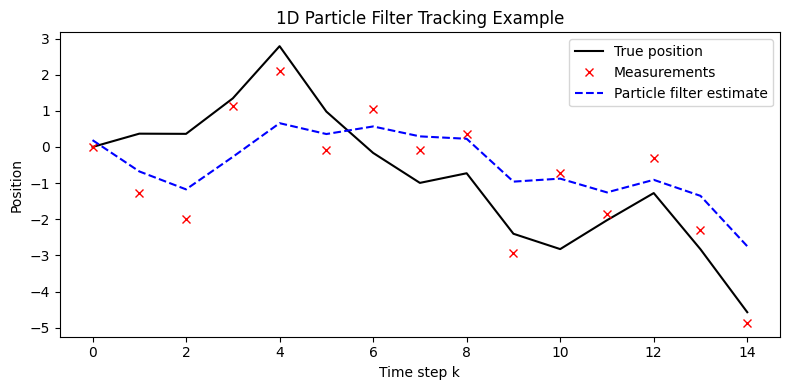

In [90]:
plt.figure(figsize=(8,4))
plt.plot(x_true, "k-", label="True position")
plt.plot(z_meas, "rx", label="Measurements")
plt.plot(x_est, "b--", label="Particle filter estimate")
plt.xlabel("Time step k")
plt.ylabel("Position")
plt.legend()
plt.title("1D Particle Filter Tracking Example")
plt.tight_layout()
plt.show()

In [ ]:
#lab
#1 random all rules change val
#does not make "choice", whatever it guesses, it flawlessly infers the results of the choice


#2random sampled subset changes val
#2.1 subset changes instantly (after each turn)
#2.2 subset changes periodically (after x turns)
#2.3 subset changes dynamically (low ones drop based on threshold)


#3rules are connected (foraging?)
#subset is a group of n possible rules centered around rule x
#A -- rule similarity based on n common features? + 1 for common location "LABEC" +1 for exact feature 
#kind like feature proximity?

#B -- rule similarity based on results? number of matching passed stimuli? -- would somehow require knowing that...? -- meta- something????



#rule-based foraging based on foraging-based rules --> peak as above so below

#3.1 instant subset changes (after the exact rule x is proved wrong) 
#3.1.1 new x chosen randomly
#3.1.2 new x chosen based on weights? (make sure not to get stuck)
#relative peaks? --> read up on observation studies?

#3.2 periodic subset changes
#subset stays for n turns -> more refined local exploration?
#3.2.1 then random
#3.2.2 then by weight

#3.3 movement (dynamic)
# rules below threshold weight are dropped, new ones are sampled from the closest? 


In [ ]:
import random
import itertools
from datasets import Dataset, disable_progress_bars
from rule import *
from plotnine import *
import pandas as pd
disable_progress_bars()

In [ ]:
def rule_maker_3dims():
    """Only creates X and (Y or Z) type rules"""
    #n important features in rule
    n_dims = 3
    # select feature dimensions
    dims = [ ''.join([*a]) for i in range(1,n_dims+1) for a in itertools.combinations('lLaAbBeEcC', i) if len(a)==n_dims]
    dims = [i for i in dims if remove_dup(i) != None]

    #translate properties
    #sample from dims (unif)  -> selects a random combination of the 3 features
    pos_in_dims = random.randint(0,len(dims)-1)
    rule_abr = dims[pos_in_dims]
    rule_trans =translate_rule(rule_abr)

    # find logical connections 
    # scheme is always X and (Y or Z)
    verbal_rule = f"{rule_trans[0]} and ( {rule_trans[1]} or {rule_trans[2]} )"
    #make it formal
    formal_rule = verbal_to_formal(verbal_rule)
    eval_content_check(formal_rule)
    
    return verbal_rule, formal_rule

#add weights to all
def weights(ds,w=0):
    "resset all weights to w"
    ds.update({"w":[w]})
    return ds

def real_rule_pass_based_weights(ds,passed:bool,stim:list[int]):
    """ If rule is in accordance with real one, w +, else w - """
    passes = ds["passes"]

    last_weight = ds["w"][-1]

    if (passed and (stim in passes)) or (not passed and (stim not in passes)):
        ds["w"].append(last_weight+1)
    else:
        ds["w"].append(last_weight-1)
    return ds

def dim_3_filter(ds):
    rule = ds["rule"].split()
    l = len(rule)
    if (l ==7) and (rule[1]=="and" and rule[2] =="(" and rule[4]=="or" and rule[6] == ")"):
        return True
    else:
        return False

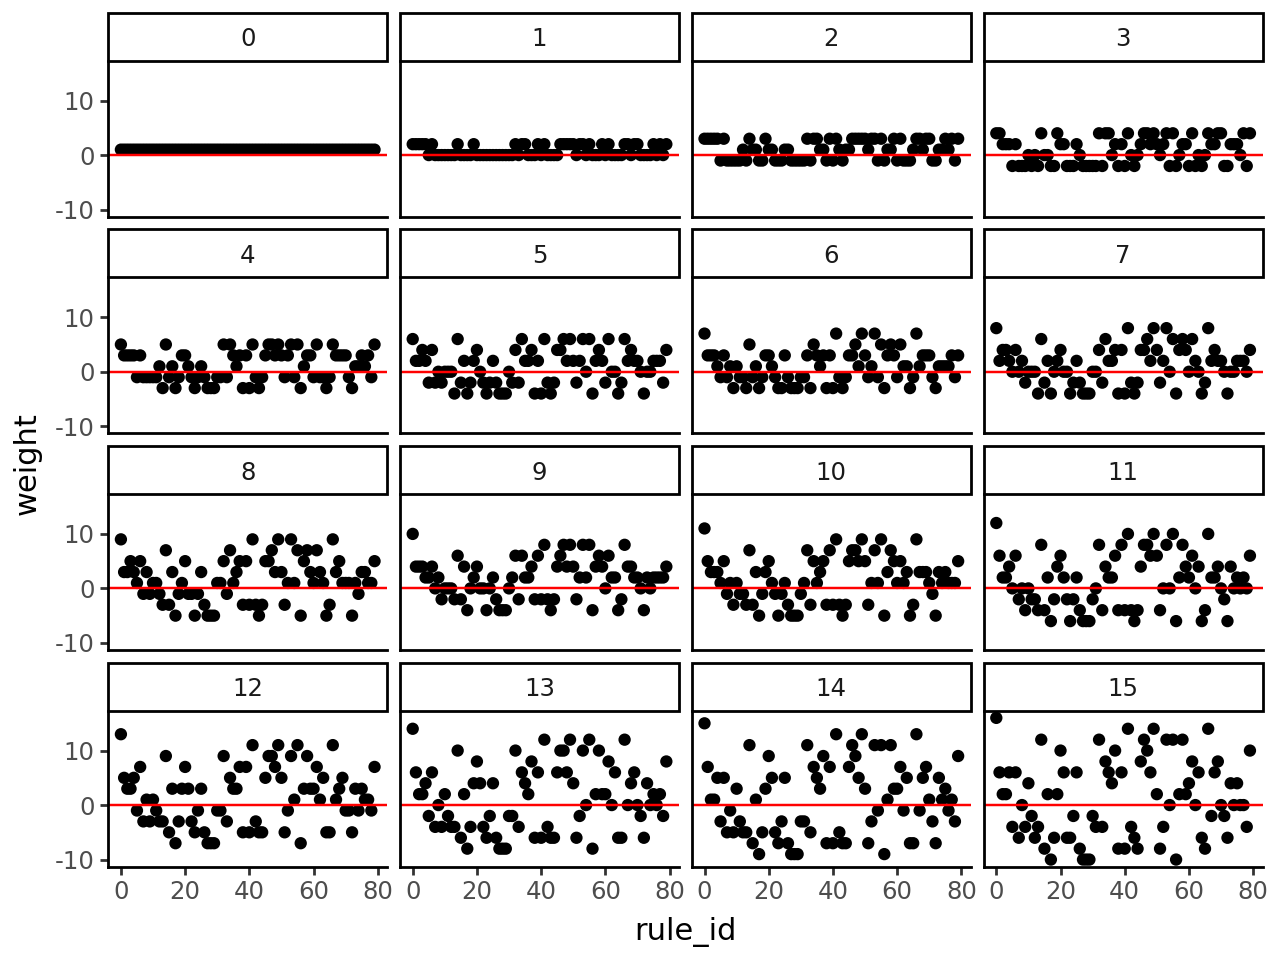

In [290]:
#filter for only 3dim rules
rule_ds = Dataset.from_parquet("rules.parquet")
ag_rules = rule_ds.filter(dim_3_filter)
true_rule = 'Thick_Legs and ( Arms_Down or Blue )'
n_t = 15
r = Rule(true_rule)
r.formalize_rule()

#init --> set weights to 1
ag_rules =ag_rules.map(weights)
for i in range(n_t):
    #get random stimuli
    stim = stimuli_maker()
    #no guesses here, this model assumes flawless information integration
    #if you say dangerous and it's correct you know that every rule that deems it dangerous gets + 
    #if you say its dangerous but it is not you know that every rule that deems it dangerous gets - 
    #check whether it is in accordance with true rule
    true_result = r.check_stimuli(stim)
    #all rules that aggree get + all rules that disagree get -
    ag_rules = ag_rules.map(real_rule_pass_based_weights, fn_kwargs={"passed":true_result,
     "stim":stim})
    

df = ag_rules.to_pandas()
w_cols = pd.DataFrame(df["w"].to_list(), columns=[i for i in range(n_t+1)])
w_cols["rule_id"] = [i for i in range(80)]

df_2 = pd.DataFrame()
df_2["rule"] = df[["rule"]]
df_2["rule_id"] = [i for i in range(80)]
df_2 = df_2.merge(w_cols, on="rule_id").melt(["rule","rule_id"],value_name="weight",var_name="turn")

(
    ggplot(df_2,aes("rule_id","weight"))
    + geom_point()
    + facet_wrap("turn")
    + geom_abline(intercept = 0, slope = 0, color = "red")
    + theme_classic()

)

In [ ]:
#prior 0.5 ( 1 out of 2) beta(1,1)
#evidence 1

In [310]:
import pymc as pm

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [ ]:
pm.draw(pm.Beta.dist(1,))

array(0.26519615)

In [472]:
#probabilities
#probability for each rule is a beta distribution
#were right / all times

#add prior probabilites to all
def set_beta_priors(ds,bp=[1,1]):
    ds.update({"beta":[bp]})
    ds.update({"mp":[bp[0]/(bp[0]+bp[1])]})
    return ds

def real_rule_pass_beta_prob(ds,passed:bool,stim:list[int]):
    """If rule is in accordance with real one, beta(x+1,y), else beta(x,y+1)"""
    passes = ds["passes"]
    #last_beta_vals = ds["beta"][-1]
    alpha = ds["beta"][-1][0]
    beta= ds["beta"][-1][1]

    if (passed and (stim in passes)) or (not passed and (stim not in passes)):
        ds["beta"].append([alpha+1,beta])
        ds["mp"].append((alpha+1)/((alpha+1)+beta))
    else:
        ds["beta"].append([alpha,beta+1])
        ds["mp"].append((alpha)/(alpha+(beta+1)))

    return ds

    

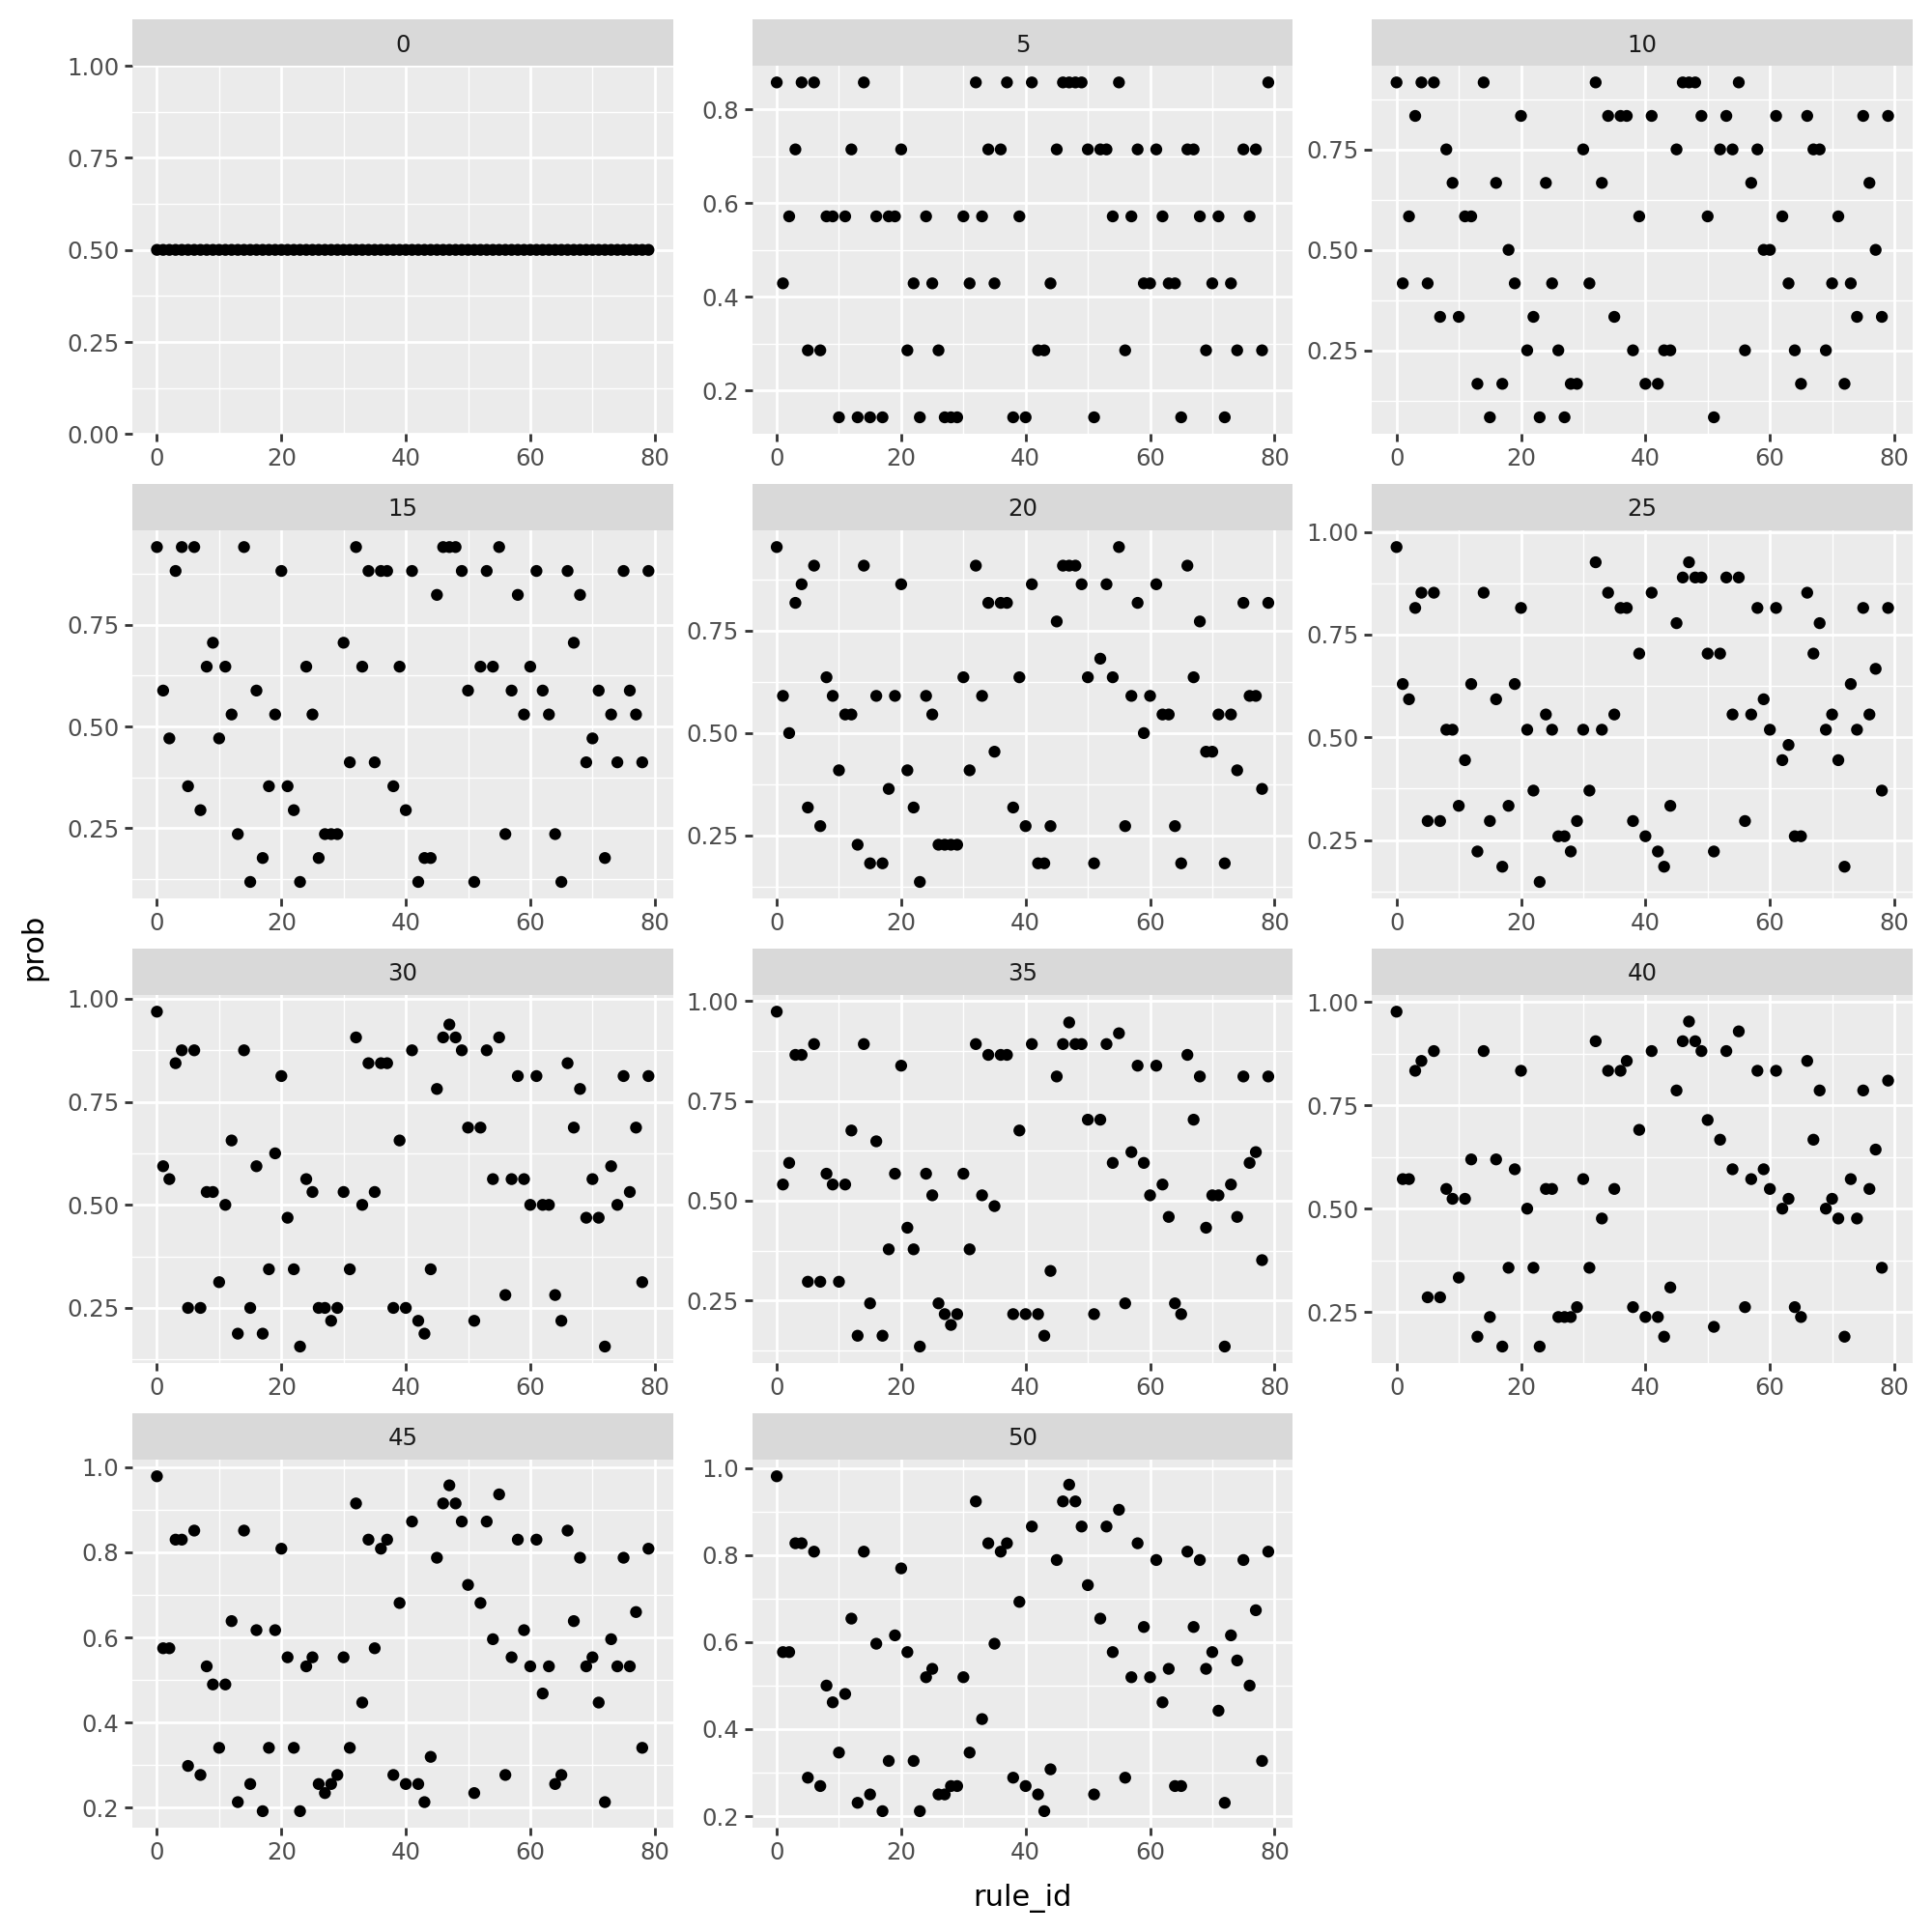

In [473]:
#filter for only 3dim rules
rule_ds = Dataset.from_parquet("rules.parquet")
ag_rules = rule_ds.filter(dim_3_filter)
true_rule = 'Thick_Legs and ( Arms_Down or Blue )'
n_t = 50
r = Rule(true_rule)
r.formalize_rule()

#init --> set weights to 1
ag_rules =ag_rules.map(set_beta_priors)
for i in range(n_t):
    #get random stimuli
    stim = stimuli_maker()
    true_result = r.check_stimuli(stim)
    #all rules that aggree get + all rules that disagree get -
    ag_rules = ag_rules.map(real_rule_pass_beta_prob, fn_kwargs={"passed":true_result,
     "stim":stim})

##wrangle the data
df = ag_rules.to_pandas()
p_cols = pd.DataFrame(df["mp"].to_list(), columns=[i for i in range(n_t+1)])
p_cols["rule_id"] = [i for i in range(80)]
beta_cols = pd.DataFrame(df["beta"].to_list(), columns=[i for i in range(n_t+1)])
beta_cols["rule_id"] = [i for i in range(80)]

df_2 = pd.DataFrame()
df_2["rule"] = df[["rule"]]
df_2["rule_id"] = [i for i in range(80)]
df_probs = df_2.merge(p_cols, on="rule_id").melt(["rule","rule_id"],value_name="prob",var_name="turn")
df_betas = df_2.merge(beta_cols, on="rule_id").melt(["rule","rule_id"],value_name="beta",var_name="turn")


#select the first 5 rules every 5th turn for visualizing the whole beta dist change
df_betas = df_betas[(df_betas["rule_id"] < 5) & (df_betas["turn"]%5==0)].reset_index()
#sample 100 vals from the betas
abcols = pd.DataFrame(df_betas["beta"].to_list(), columns=["a","b"])
df_betas["a"]= abcols["a"]
df_betas["b"]= abcols["b"]
draws = [pm.draw(pm.Beta.dist(a,b),100) for a,b in zip(df_betas["a"],df_betas["b"])]
df_betas["draws"] = draws
draw_cols = pd.DataFrame(df_betas["draws"].to_list(), columns=[i for i in range(100)])

df_betas= df_betas[["rule","rule_id","turn","beta","a","b"]].join(draw_cols).melt(["rule","rule_id","turn","beta","a","b"],var_name="draw")
df_betas["rule_id"] = df_betas["rule_id"].astype(str)

#select every 5th turn for displaying
(
    ggplot(df_probs[df_probs["turn"]%5==0],aes("rule_id","prob"))
    + geom_point()
    + facet_wrap("turn",ncol=3,scales="free",shrink=False)
    + theme(figure_size=(10,10))

)

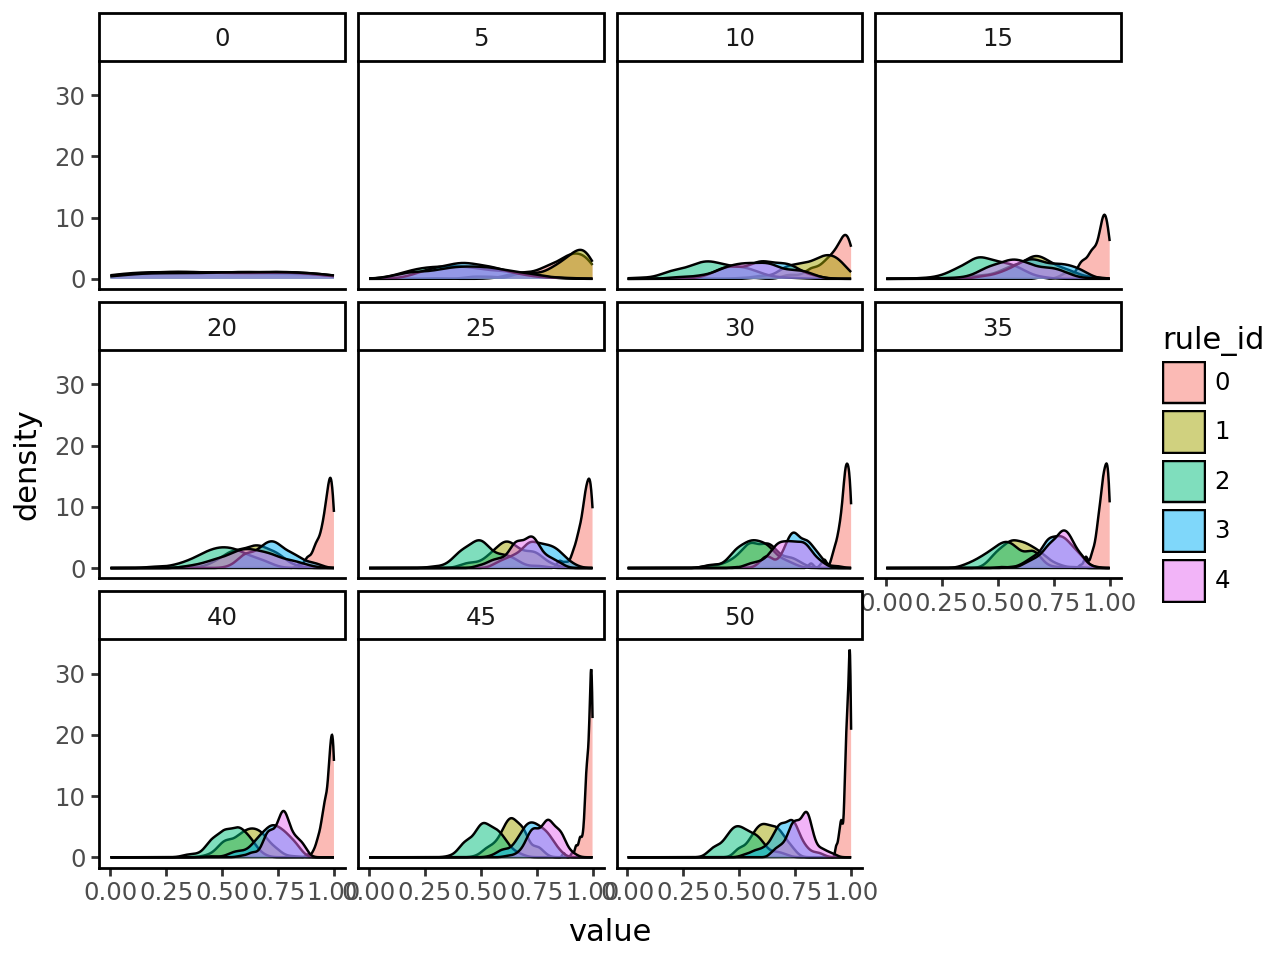

In [469]:
(
    ggplot(df_betas,aes("value",group="rule_id",fill="rule_id"))
           +geom_density(alpha= 0.5)
           +facet_wrap("turn")
           +theme_classic()
    )

In [ ]:
#2